<a href="https://colab.research.google.com/github/fkanellos/football-tactical-engine/blob/main/research/00_setup_sn_gamestate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 - Setup: SoccerNet Game State Reconstruction (sn-gamestate)

This notebook sets up a Python 3.9 environment on Google Colab, installs [SoccerNet/sn-gamestate](https://github.com/SoccerNet/sn-gamestate) and its [TrackLab](https://github.com/TrackingLaboratory/tracklab) dependency, and runs the default game state reconstruction demo on a SoccerNet validation sequence.

**Run this in Google Colab** (not locally) — later cells assume a Colab VM.

In [8]:
import subprocess
print(subprocess.run("nvidia-smi --query-gpu=utilization.gpu,memory.used --format=csv", shell=True, capture_output=True, text=True).stdout)
print("PROCS:", subprocess.run("nvidia-smi --query-compute-apps=pid,used_memory --format=csv", shell=True, capture_output=True, text=True).stdout)
print("LOG TAIL:", subprocess.run("tail -3 /content/run_log.txt", shell=True, capture_output=True, text=True).stdout)
print("OUT FILES:", subprocess.run("find /content/sn-gamestate/outputs/video-demo -type f | tail -5", shell=True, capture_output=True, text=True).stdout)

utilization.gpu [%], memory.used [MiB]
0 %, 0 MiB

PROCS: pid, used_gpu_memory [MiB]

LOG TAIL:                              (val) has no                           
                             ground truth                           
                             detections.                            

OUT FILES: /content/sn-gamestate/outputs/video-demo/2026-07-15/12-49-14/configs/config.yaml
/content/sn-gamestate/outputs/video-demo/2026-07-15/12-19-03/main.log
/content/sn-gamestate/outputs/video-demo/2026-07-15/12-19-03/configs/hydra.yaml
/content/sn-gamestate/outputs/video-demo/2026-07-15/12-19-03/configs/overrides.yaml
/content/sn-gamestate/outputs/video-demo/2026-07-15/12-19-03/configs/config.yaml



In [9]:
y import Image, display
for f in ["/content/ofi_anno_01.jpg","/content/ofi_anno_02.jpg","/content/ofi_anno_03.jpg"]:
    display(Image(filename=f, width=820))

SyntaxError: invalid syntax (44492983.py, line 1)

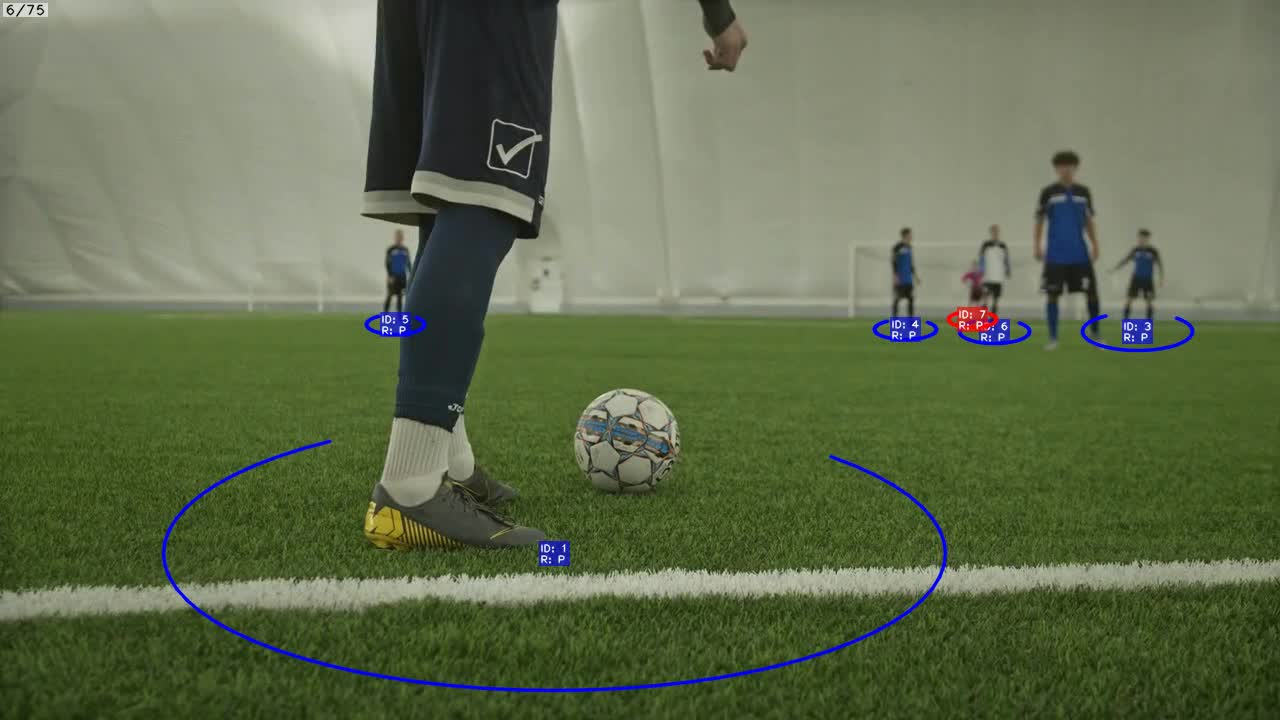

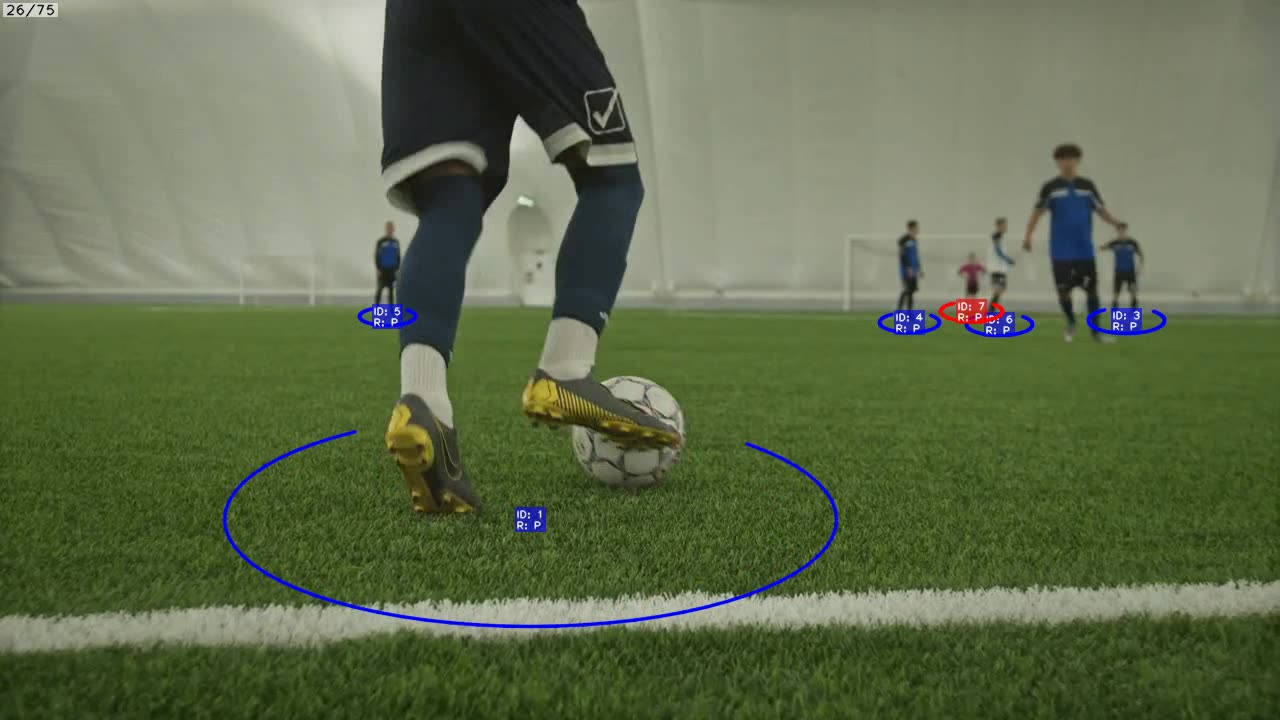

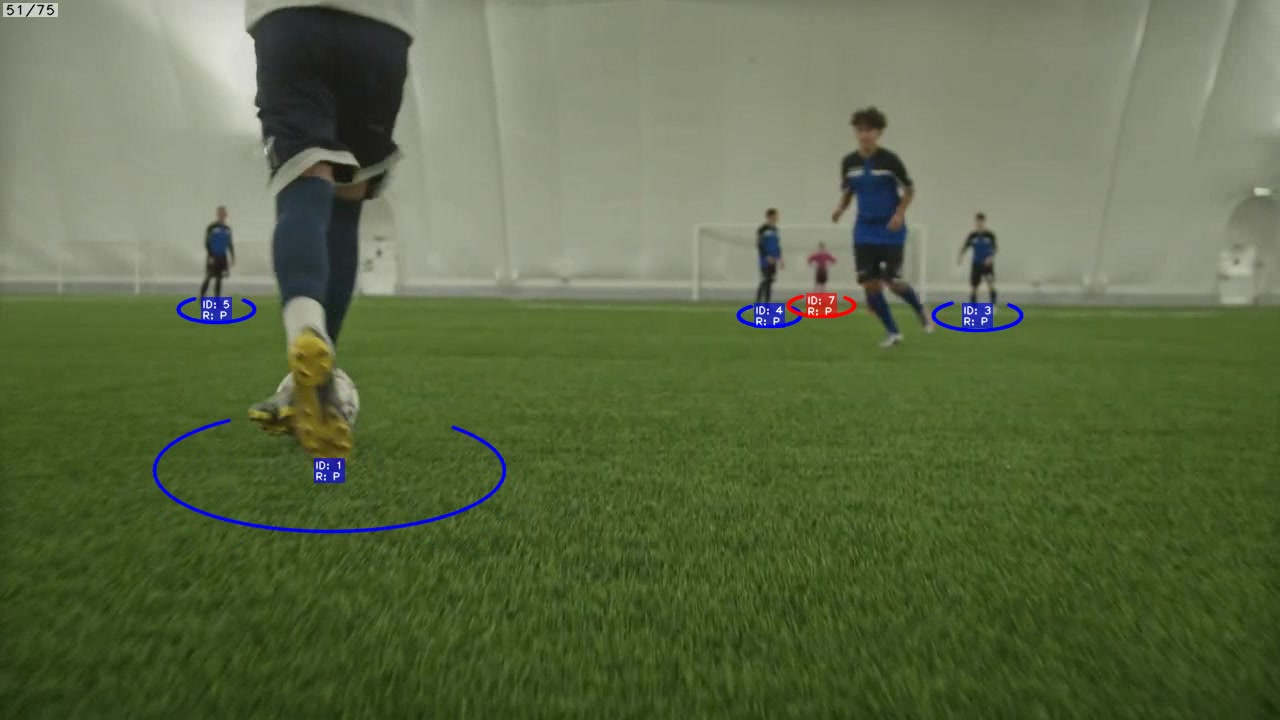

In [7]:
from IPython.display import Image, display
for f in ["/content/anno_01.jpg","/content/anno_02.jpg","/content/anno_03.jpg"]:
    display(Image(filename=f, width=760))

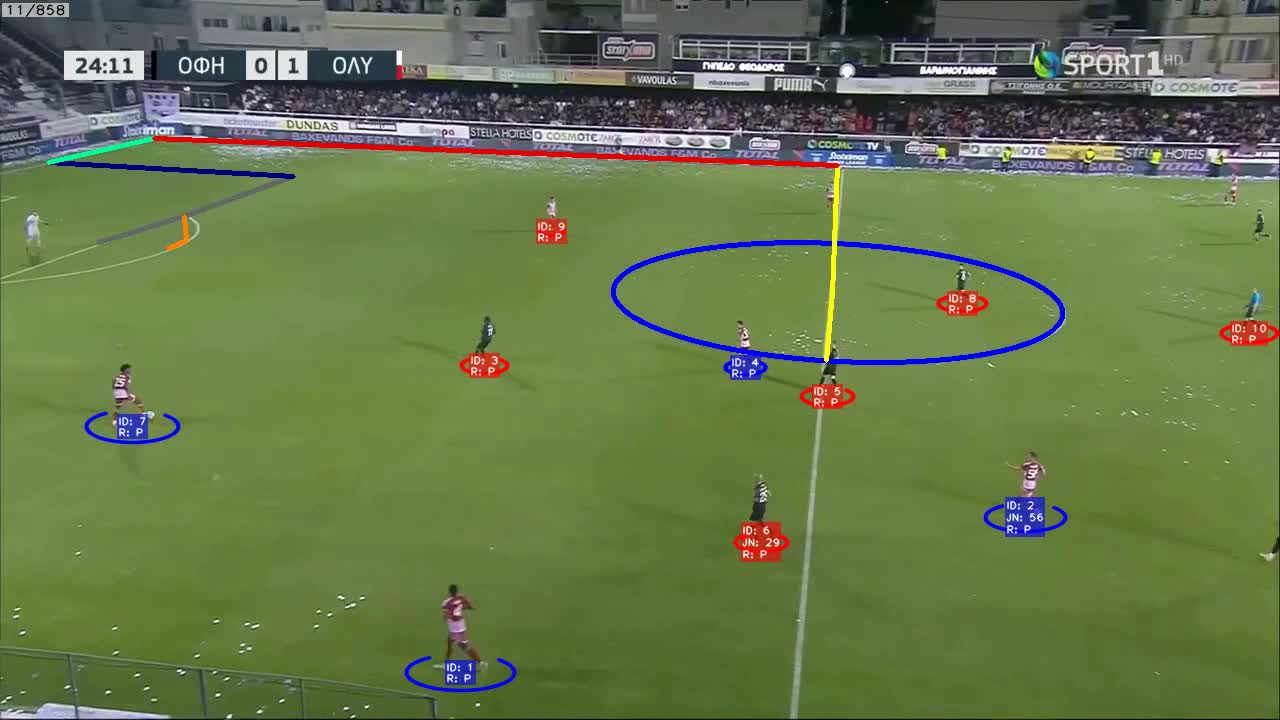

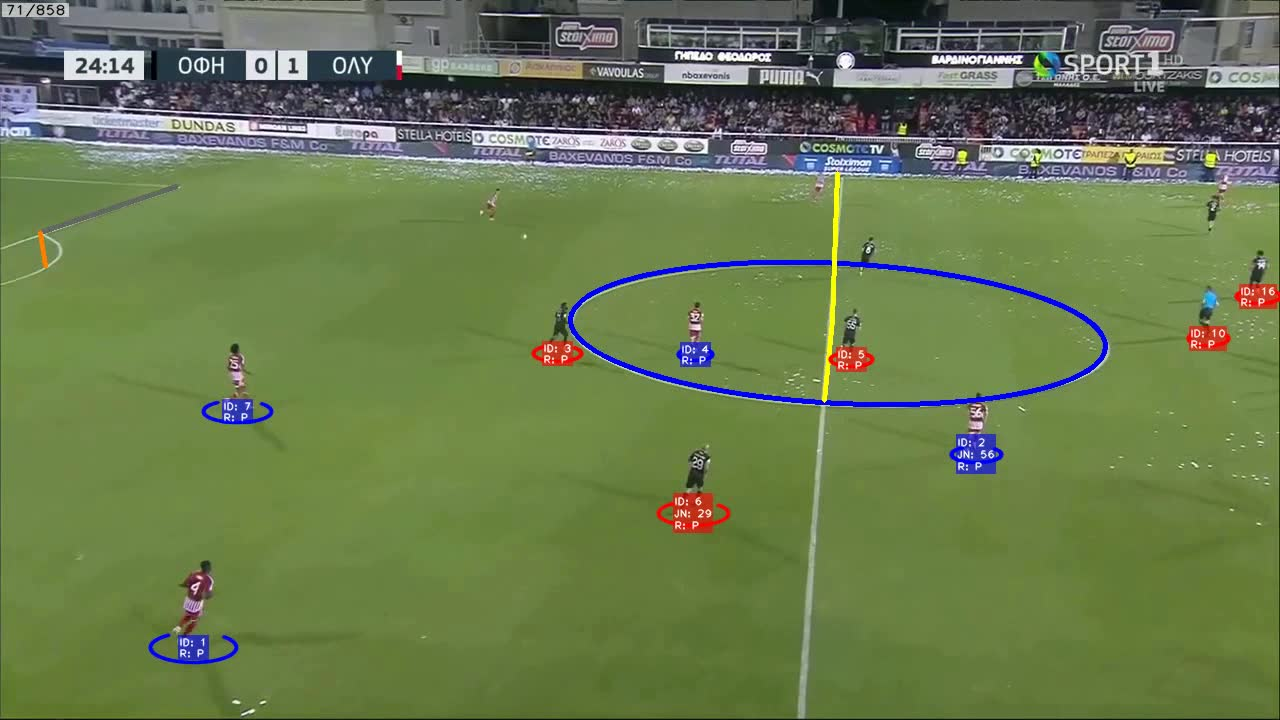

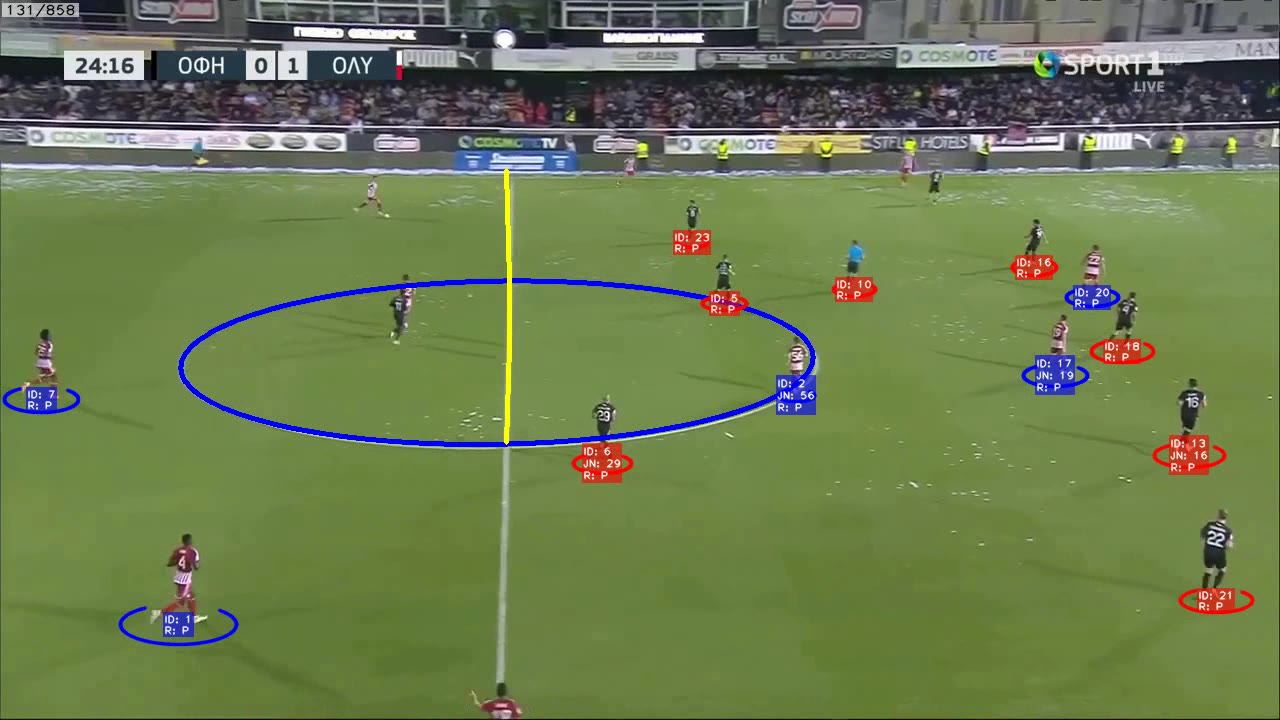

In [10]:
from IPython.display import Image, display
for f in ["/content/ofi_anno_01.jpg","/content/ofi_anno_02.jpg","/content/ofi_anno_03.jpg"]:
    display(Image(filename=f, width=820))

## 1. Set up the environment (one-shot terminal script)

We do the full environment setup with [`research/setup.sh`](setup.sh) run from a terminal, **not** as notebook cells.

**Why not just run apt/uv in cells?** Two reasons, both Colab quirks we hit during setup:

1. **Drive persistence is broken.** Colab's Drive mount currently invokes the wrong OAuth client ("Google Drive for desktop" instead of "Google Colaboratory") and fails with *"credential propagation was unsuccessful"* ([colabtools#5944](https://github.com/googlecolab/colabtools/issues/5944)). So we **cannot persist installs across VM restarts** — every fresh/disconnected VM needs a full re-install. That's tolerable only if setup is a single unattended command.
2. **Running the installs as notebook cells is unreliable** — long apt/uv steps don't survive a notebook disconnect. Running the script under `nohup` in the background does.

`setup.sh` must be run from **inside a clone of this repo** (it invokes itself via the `research/setup.sh` relative path), so the first step is always to clone `fkanellos/football-tactical-engine` into `/content` on the fresh Colab VM. Open a **Terminal** in Colab (or prefix each line with `!` in a cell) and run:


In [ ]:
# Run this ONCE per fresh Colab VM, from a Colab Terminal (or prefix each line with ! in a cell).
#
# 1. Clone our repo into /content (setup.sh runs from inside it, via the research/ relative path):
#      git clone https://github.com/fkanellos/football-tactical-engine.git /content/football-tactical-engine
#
# 2. From inside that clone, launch setup in the background so it survives notebook disconnects:
#      cd /content/football-tactical-engine
#      nohup bash research/setup.sh > /content/install_log.txt 2>&1 &
#
# 3. Follow progress:
#      tail -f /content/install_log.txt
#
# Wait for the 'DONE' banner, then switch this notebook's kernel to
# 'Python 3.9 (sn-gamestate)' (kernel picker, top-right) before running the cells below.

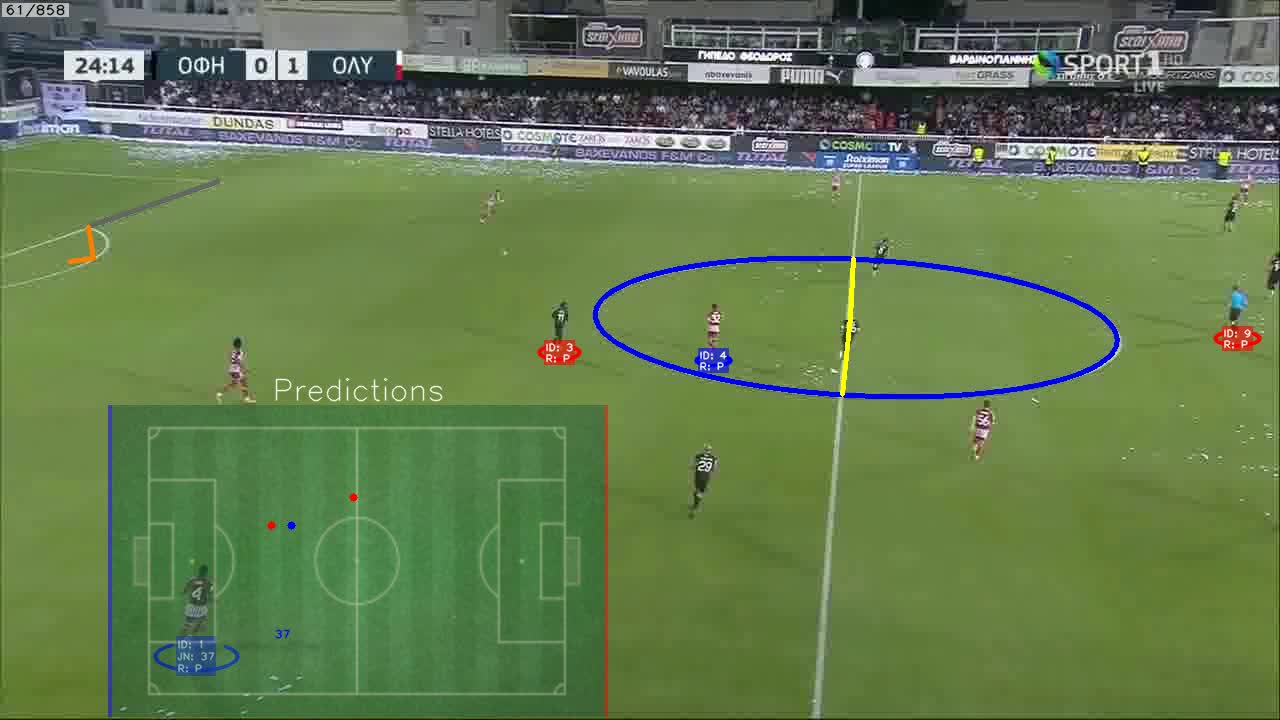

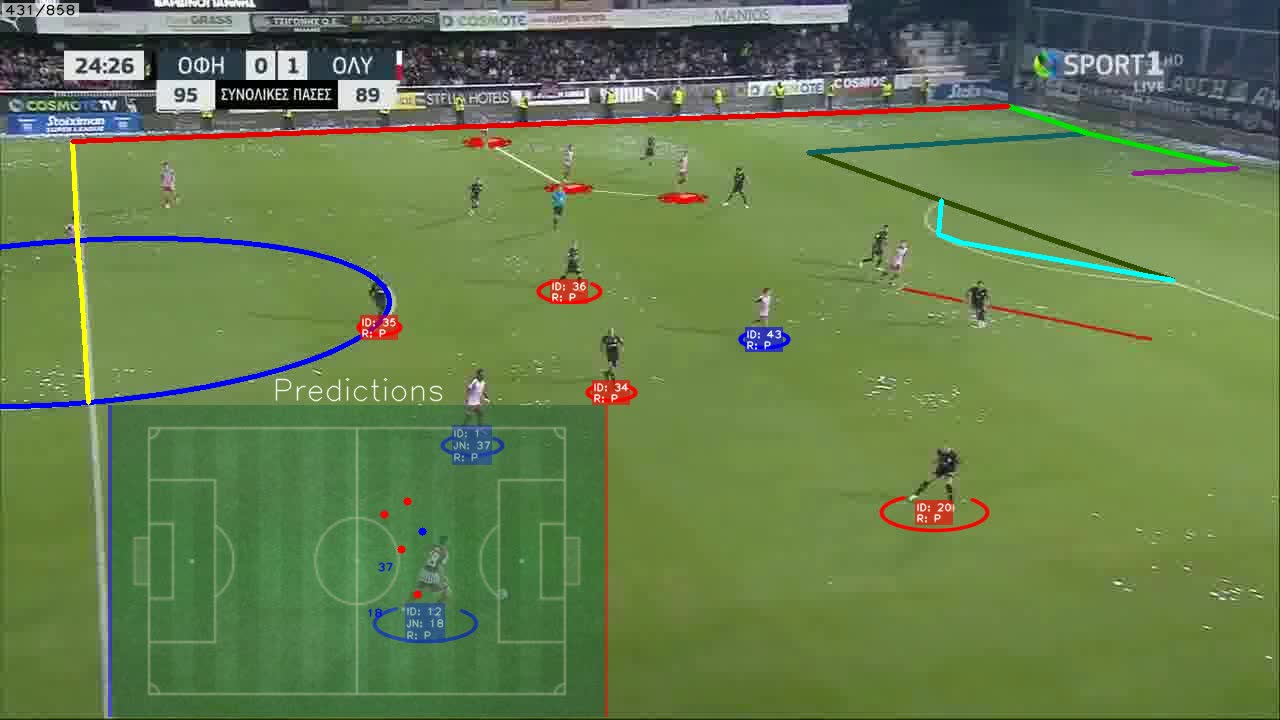

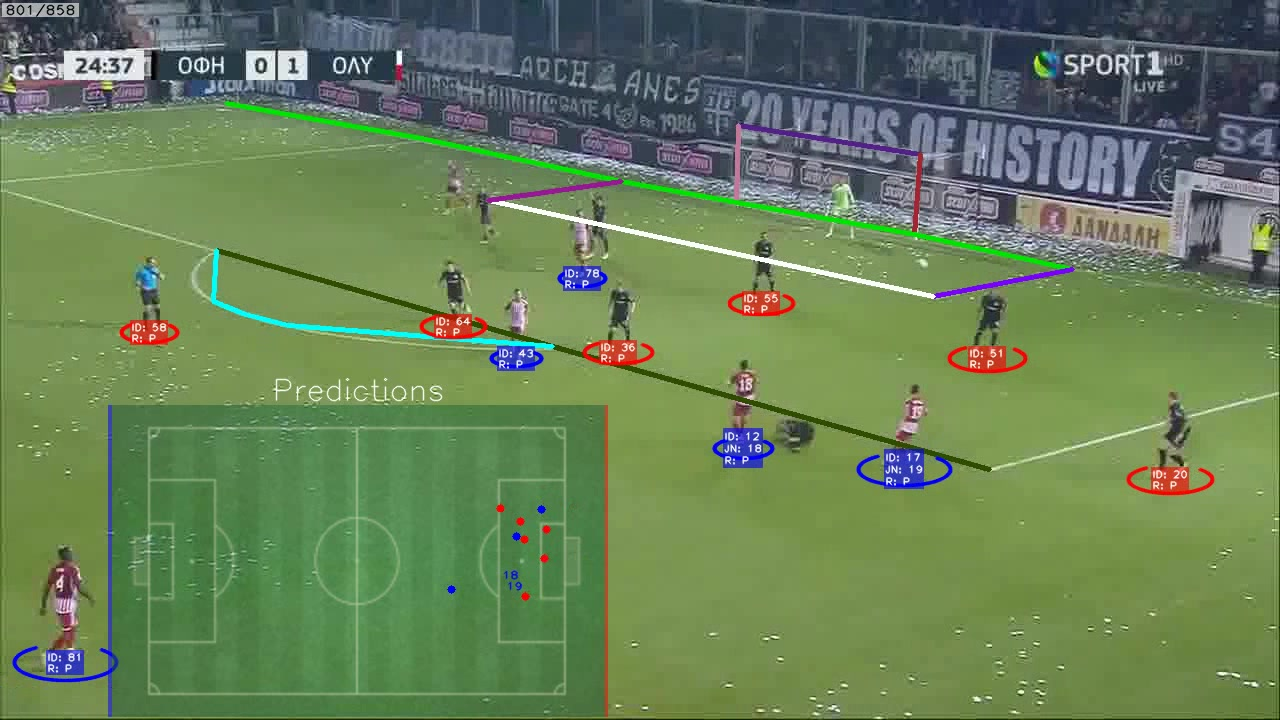

In [1]:
from IPython.display import Image, display
for f in ['/content/full_01.jpg','/content/full_02.jpg','/content/full_03.jpg']:
    display(Image(filename=f, width=900))

## 2. Dataset and model weights

This notebook does **not** bundle the SoccerNet dataset or model weights. TrackLab automatically downloads the SoccerNet-gamestate dataset and all required model weights the first time the pipeline is run below — this will take a while on first run (multiple GB) and requires accepting the SoccerNet dataset terms when prompted. Subsequent runs reuse the cached data under the `data_dir` configured in `sn_gamestate/configs/soccernet.yaml`.

## 3. Run the default game state reconstruction demo

Make sure setup has finished (the `DONE` banner) and that this notebook's kernel is set to **Python 3.9 (sn-gamestate)** (kernel picker, top-right) before running this.

Runs the default `soccernet` config, which processes one SoccerNet validation sequence end-to-end (detection, tracking, calibration, jersey/team classification, game state reconstruction).

In [ ]:
%%bash
set -e
export PATH="$HOME/.local/bin:$PATH"
cd /content/sn-gamestate
uv run tracklab -cn soccernet

## 4. Visualize the output

The demo writes an annotated video (tracking overlays + 2D pitch minimap) under `outputs/{date}/{time}/visualization/videos/`. The cell below finds the most recently produced video and displays it inline.

In [ ]:
import glob
import os
from IPython.display import Video

candidates = glob.glob("/content/sn-gamestate/outputs/**/visualization/videos/*.mp4", recursive=True)
assert candidates, "No output video found — check that the demo cell above completed successfully."
latest = max(candidates, key=os.path.getmtime)
print(f"Displaying: {latest}")
Video(latest, embed=True, width=800)